In [1]:
import rasterio

with rasterio.open("tehri_landslide/data/soil/hwsd.bil") as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)
    print("Width, Height:", src.width, src.height)
    print("Count of bands:", src.count)
    print("Driver:", src.driver)
    print("Dtype:", src.dtypes)


CRS: None
Resolution: (0.00833333333333, 0.00833333333333)
NoData: None
Bounds: BoundingBox(left=-180.0, bottom=-89.99999999999997, right=179.99999999985602, top=89.99999999992804)
Width, Height: 43200 21600
Count of bands: 1
Driver: EHdr
Dtype: ('uint16',)


In [2]:
from rasterio.crs import CRS

with rasterio.open("tehri_landslide/data/soil/hwsd.bil", "r+") as src:
    src.crs = CRS.from_epsg(4326)

print("CRS assigned to HWSD")

CRS assigned to HWSD


In [3]:
src.crs

CRS.from_epsg(4326)

In [5]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

src_path = "tehri_landslide/data/soil/hwsd.bil"
dst_path = "tehri_landslide/data/soil_features/HWSD_32644.tif"

with rasterio.open(src_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, "EPSG:32644",
        src.width, src.height,
        *src.bounds
    )

    meta = src.meta.copy()
    meta.update({
        "crs": "EPSG:32644",
        "transform": transform,
        "width": width,
        "height": height,
        "nodata": src.nodata
    })

    with rasterio.open(dst_path, "w", **meta) as dst:
        reproject(
            source=src.read(1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs="EPSG:32644",
            resampling=Resampling.nearest  # categorical
        )

print("HWSD reprojected to EPSG:32644")


HWSD reprojected to EPSG:32644


In [7]:
import geopandas as gpd
from rasterio.mask import mask

tehri = gpd.read_file("F:/New Folder (2)/tehri_new/tehri.shp")

with rasterio.open("tehri_landslide/data/soil_features/HWSD_32644.tif") as src:
    out_img, out_transform = mask(
        src,
        tehri.geometry,
        crop=True,
        nodata=src.nodata
    )

    meta = src.meta.copy()
    meta.update({
        "height": out_img.shape[1],
        "width": out_img.shape[2],
        "transform": out_transform
    })

    with rasterio.open("tehri_landslide/data/soil_features/HWSD_Tehri.tif", "w", **meta) as dst:
        dst.write(out_img)

print("HWSD clipped to Tehri")

HWSD clipped to Tehri


In [8]:
import numpy as np
from rasterio.warp import reproject, Resampling

with rasterio.open("tehri_landslide/data/DEM/DEM_Tehri_clean.tif") as dem, \
     rasterio.open("tehri_landslide/data/soil_features/HWSD_Tehri.tif") as soil:

    dst = np.empty((dem.height, dem.width), dtype=soil.read(1).dtype)

    reproject(
        source=soil.read(1),
        destination=dst,
        src_transform=soil.transform,
        src_crs=soil.crs,
        dst_transform=dem.transform,
        dst_crs=dem.crs,
        resampling=Resampling.nearest
    )

    meta = dem.meta.copy()
    meta.update({
        "dtype": dst.dtype,
        "nodata": soil.nodata
    })

    with rasterio.open("tehri_landslide/data/soil_features/Soil_Tehri.tif", "w", **meta) as out:
        out.write(dst, 1)

print("Soil layer aligned to DEM grid")


Soil layer aligned to DEM grid


In [9]:
soil_path = "tehri_landslide/data/soil_features/Soil_Tehri.tif"

with rasterio.open(soil_path) as src:
    soil = src.read(1)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Shape:", soil.shape)

    # mask nodata
    soil_valid = soil[soil != src.nodata]

    print("Unique soil classes (sample):", np.unique(soil_valid)[:20])
    print("Total unique classes:", len(np.unique(soil_valid)))

CRS: EPSG:32644
Resolution: (27.116912536875038, 27.116912536875038)
NoData: None
Shape: (3351, 3962)
Unique soil classes (sample): [   0 3661 3671 3717]
Total unique classes: 4


In [10]:
print(
    "Min class:", soil_valid.min(),
    "Max class:", soil_valid.max()
)

Min class: 0 Max class: 3717


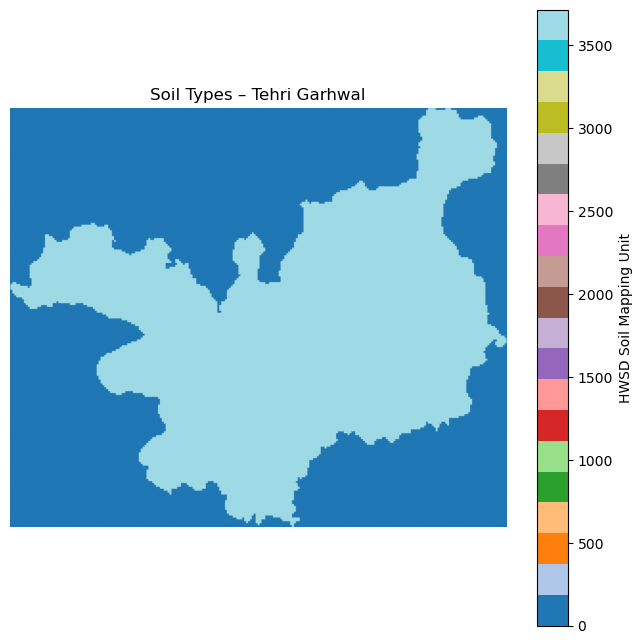

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(soil, cmap="tab20")
plt.colorbar(label="HWSD Soil Mapping Unit")
plt.title("Soil Types – Tehri Garhwal")
plt.axis("off")
plt.show()